# Grocery Data Pattern Mining Analysis

This notebook explores the grocery transaction dataset and implements pattern mining techniques to discover frequent itemsets and association rules. We'll explore the data first, then implement the pattern mining algorithm.

## 1. Data Exploration and Preprocessing

load and explore the dataset to understand its structure

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
from itertools import combinations
import math

# Set plot style
plt.style.use('ggplot')
sns.set(font_scale=1.2)

In [2]:
# Load the training data
train_data = pd.read_csv('Groceries data train.csv')

# Check basic info
print(f"Dataset shape: {train_data.shape}")
train_data.head()


Dataset shape: (19382, 7)


,User_id,Date,itemDescription,year,month,day,day_of_week
0,2351,1/01/2014,cleaner,2014,1,1,2
1,2226,1/01/2014,sausage,2014,1,1,2
2,1922,1/01/2014,tropical fruit,2014,1,1,2
3,2943,1/01/2014,whole milk,2014,1,1,2
4,1249,1/01/2014,citrus fruit,2014,1,1,2


examine the data types and check for missing values:

In [3]:
# Data types and missing values
train_data.info()
print("\nMissing values:")
print(train_data.isnull().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19382 entries, 0 to 19381
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   User_id          19382 non-null  int64 
 1   Date             19382 non-null  object
 2   itemDescription  19382 non-null  object
 3   year             19382 non-null  int64 
 4   month            19382 non-null  int64 
 5   day              19382 non-null  int64 
 6   day_of_week      19382 non-null  int64 
dtypes: int64(5), object(2)
memory usage: 1.0+ MB

Missing values:
User_id            0
Date               0
itemDescription    0
year               0
month              0
day                0
day_of_week        0
dtype: int64


convert the date to proper datetime format for analysis:

In [4]:
# Convert date to datetime
train_data['Date'] = pd.to_datetime(train_data['Date'], format='%d/%m/%Y')

# Add some temporal features
train_data['week'] = train_data['Date'].dt.isocalendar().week
train_data['month_name'] = train_data['Date'].dt.month_name()

# Verify date conversion
print("Date range:", train_data['Date'].min(), "to", train_data['Date'].max())
train_data.head()

Date range: 2014-01-01 00:00:00 to 2015-01-20 00:00:00


,User_id,Date,itemDescription,year,month,day,day_of_week,week,month_name
0,2351,2014-01-01,cleaner,2014,1,1,2,1,January
1,2226,2014-01-01,sausage,2014,1,1,2,1,January
2,1922,2014-01-01,tropical fruit,2014,1,1,2,1,January
3,2943,2014-01-01,whole milk,2014,1,1,2,1,January
4,1249,2014-01-01,citrus fruit,2014,1,1,2,1,January


### 1.1 Exploratory Data Analysis  
analyze the basic characteristics of our dataset:

In [5]:
# Number of unique users and items
print(f"Number of unique users: {train_data['User_id'].nunique()}")
print(f"Number of unique items: {train_data['itemDescription'].nunique()}")

# Count transactions (unique user-date combinations)
transactions = train_data.groupby(['User_id', 'Date'])['itemDescription'].count()
print(f"Number of transactions: {len(transactions)}")
print(f"Average items per transaction: {transactions.mean():.2f}")

Number of unique users: 3493
Number of unique items: 167
Number of transactions: 8361
Average items per transaction: 2.32


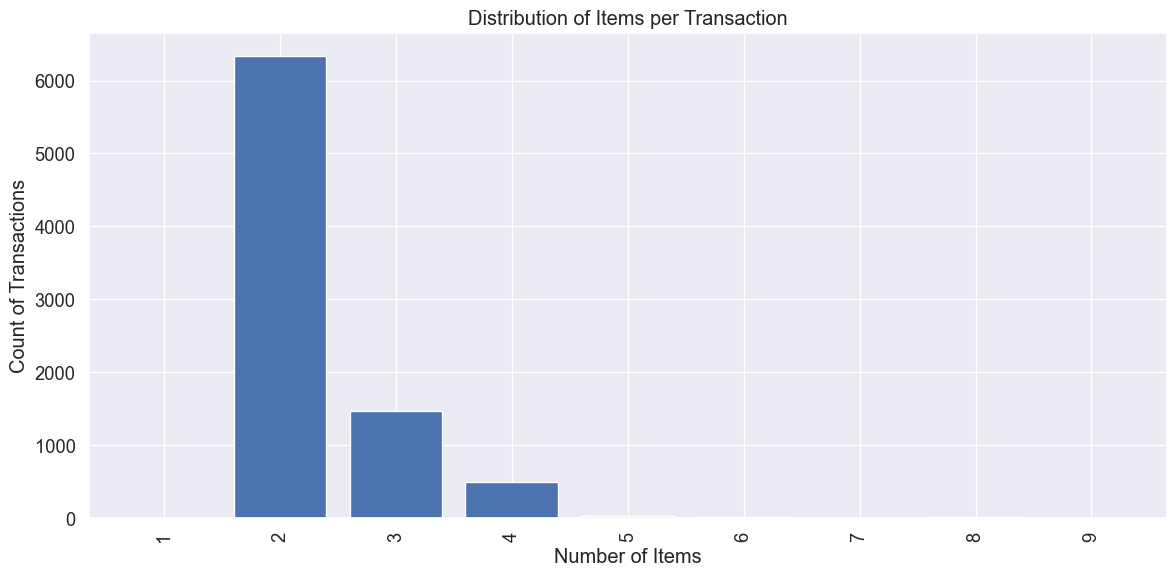

In [6]:
# Distribution of transaction sizes
plt.figure(figsize=(12, 6))
transactions.value_counts().sort_index().plot(kind='bar', width=0.8)
plt.title('Distribution of Items per Transaction')
plt.xlabel('Number of Items')
plt.ylabel('Count of Transactions')
plt.tight_layout()
plt.show()

the most popular items:

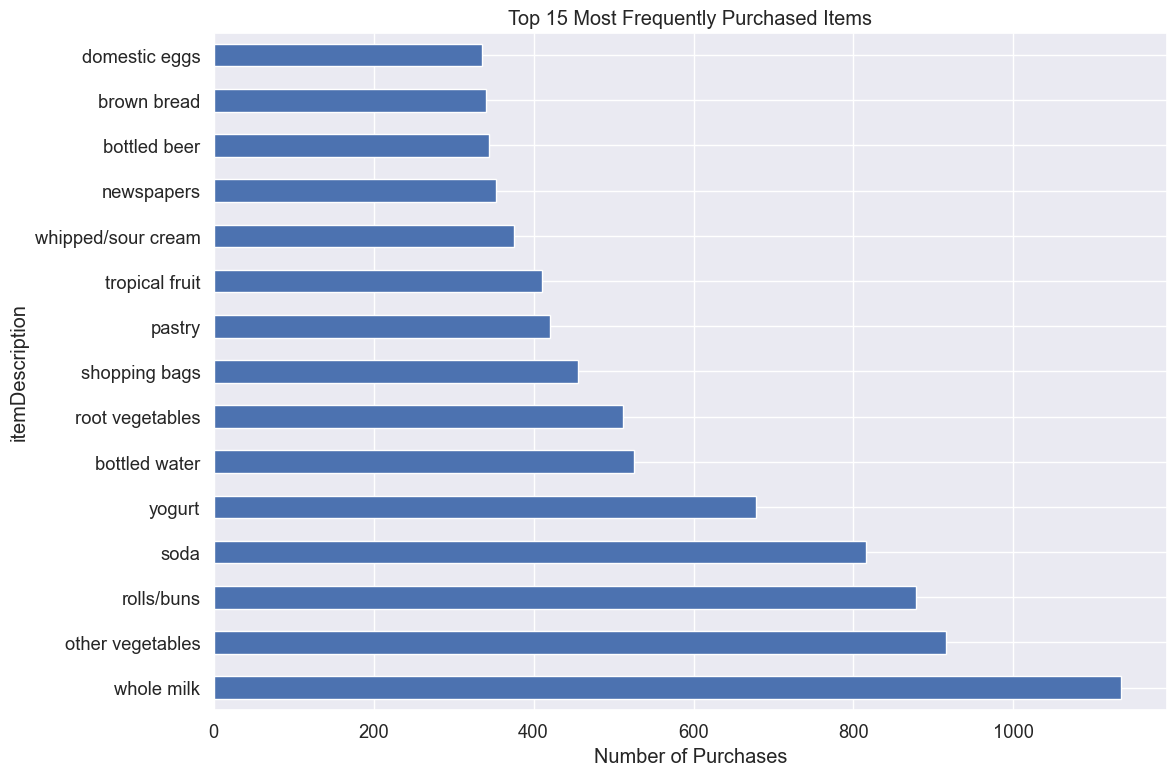

In [7]:
# Most frequent items
item_counts = train_data['itemDescription'].value_counts()
top_items = item_counts.head(15)

plt.figure(figsize=(12, 8))
top_items.plot(kind='barh')
plt.title('Top 15 Most Frequently Purchased Items')
plt.xlabel('Number of Purchases')
plt.tight_layout()
plt.show()

In [8]:
# Show the percentage of total purchases
print("Top items as percentage of all purchases:")
total = len(train_data)
for item, count in top_items.items():
    print(f"{item}: {count/total*100:.2f}%")

Top items as percentage of all purchases:
whole milk: 5.86%
other vegetables: 4.73%
rolls/buns: 4.53%
soda: 4.21%
yogurt: 3.50%
bottled water: 2.71%
root vegetables: 2.64%
shopping bags: 2.35%
pastry: 2.17%
tropical fruit: 2.12%
whipped/sour cream: 1.94%
newspapers: 1.82%
bottled beer: 1.77%
brown bread: 1.76%
domestic eggs: 1.73%


how purchases distribute across days of the week:

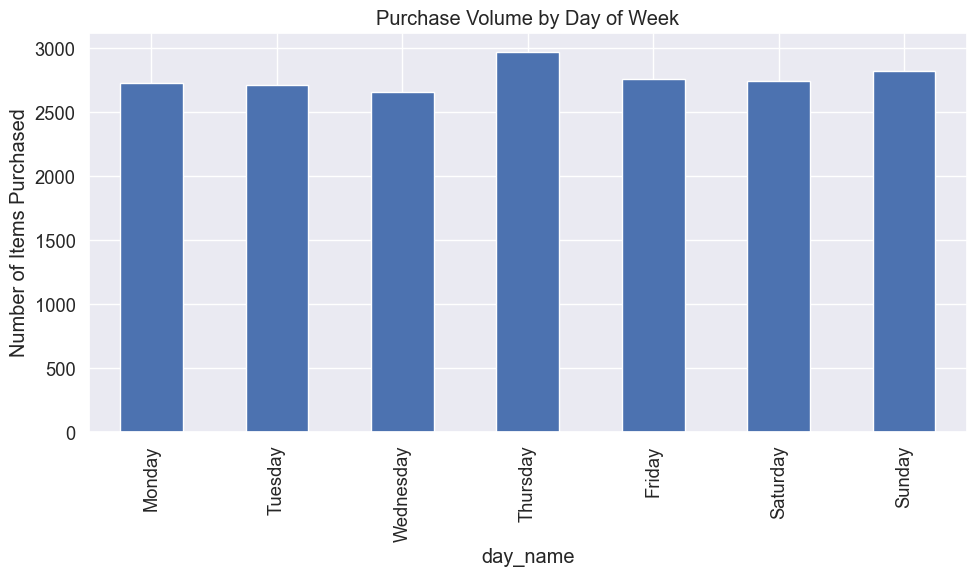

In [9]:
# Purchases by day of week
day_names = {0: 'Monday', 1: 'Tuesday', 2: 'Wednesday', 
             3: 'Thursday', 4: 'Friday', 5: 'Saturday', 6: 'Sunday'}
train_data['day_name'] = train_data['day_of_week'].map(day_names)

plt.figure(figsize=(10, 6))
train_data['day_name'].value_counts().reindex(
    ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
).plot(kind='bar')
plt.title('Purchase Volume by Day of Week')
plt.ylabel('Number of Items Purchased')
plt.tight_layout()
plt.show()

distribution of purchases across months:

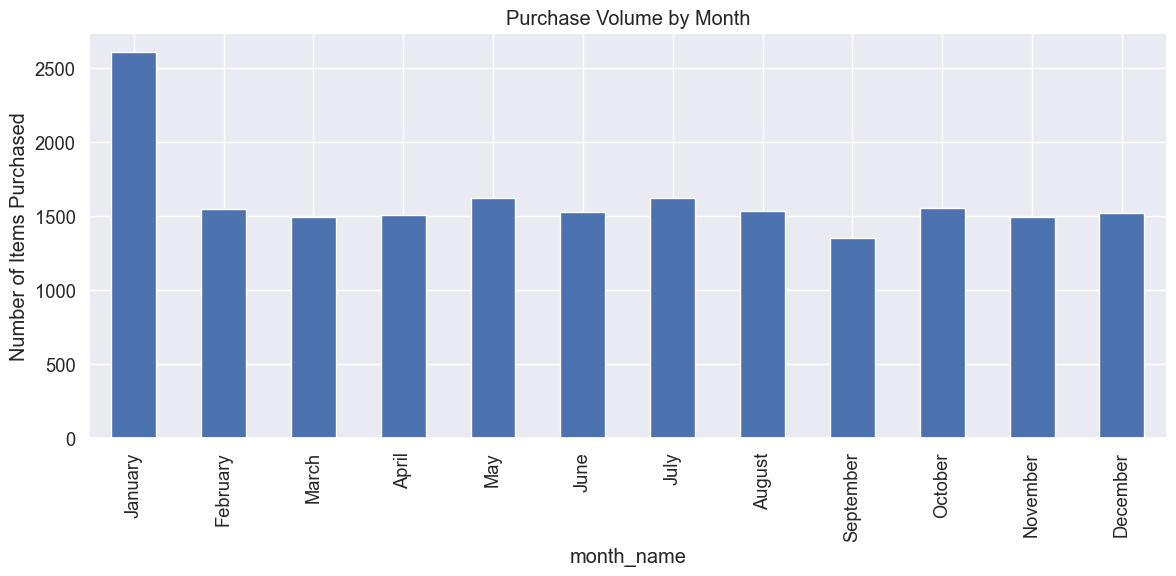

In [10]:
# Purchases by month
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']
plt.figure(figsize=(12, 6))
train_data['month_name'].value_counts().reindex(month_order).plot(kind='bar')
plt.title('Purchase Volume by Month')
plt.ylabel('Number of Items Purchased')
plt.tight_layout()
plt.show()

### 1.2 User Purchase Behavior Analysis

examine how users behave in terms of purchase frequency:

c:\Users\ASUS\.conda\envs\myenv\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


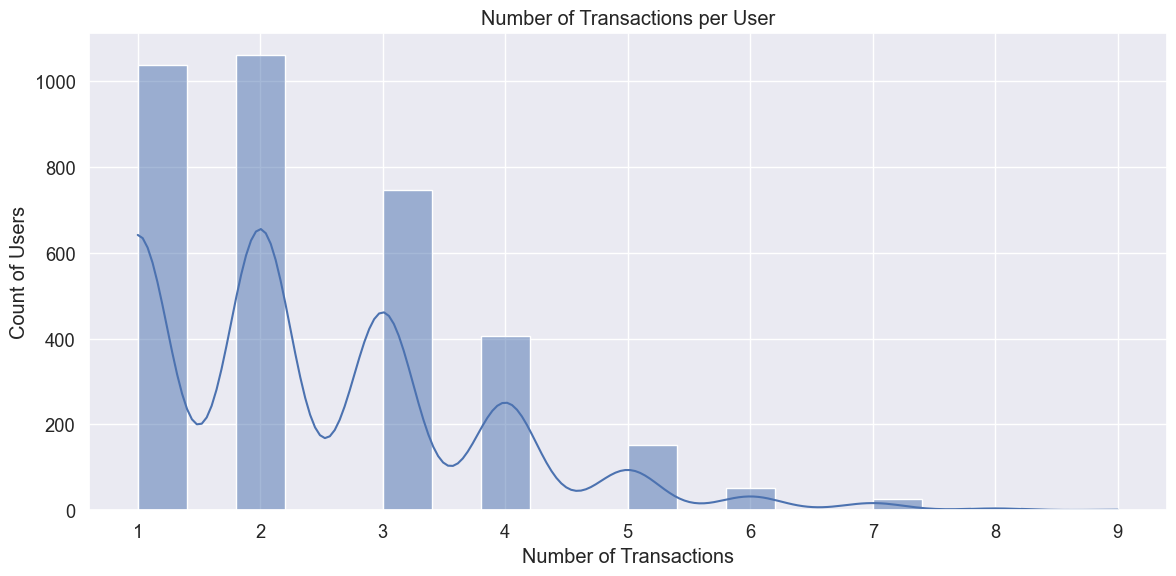

Average transactions per user: 2.39
Median transactions per user: 2.00
Max transactions per user: 9


In [11]:
# Transactions per user
user_transaction_counts = train_data.groupby('User_id')['Date'].nunique()

plt.figure(figsize=(12, 6))
sns.histplot(user_transaction_counts, bins=20, kde=True)
plt.title('Number of Transactions per User')
plt.xlabel('Number of Transactions')
plt.ylabel('Count of Users')
plt.tight_layout()
plt.show()

print(f"Average transactions per user: {user_transaction_counts.mean():.2f}")
print(f"Median transactions per user: {user_transaction_counts.median():.2f}")
print(f"Max transactions per user: {user_transaction_counts.max()}")

 patterns in the purchase time intervals:

c:\Users\ASUS\.conda\envs\myenv\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


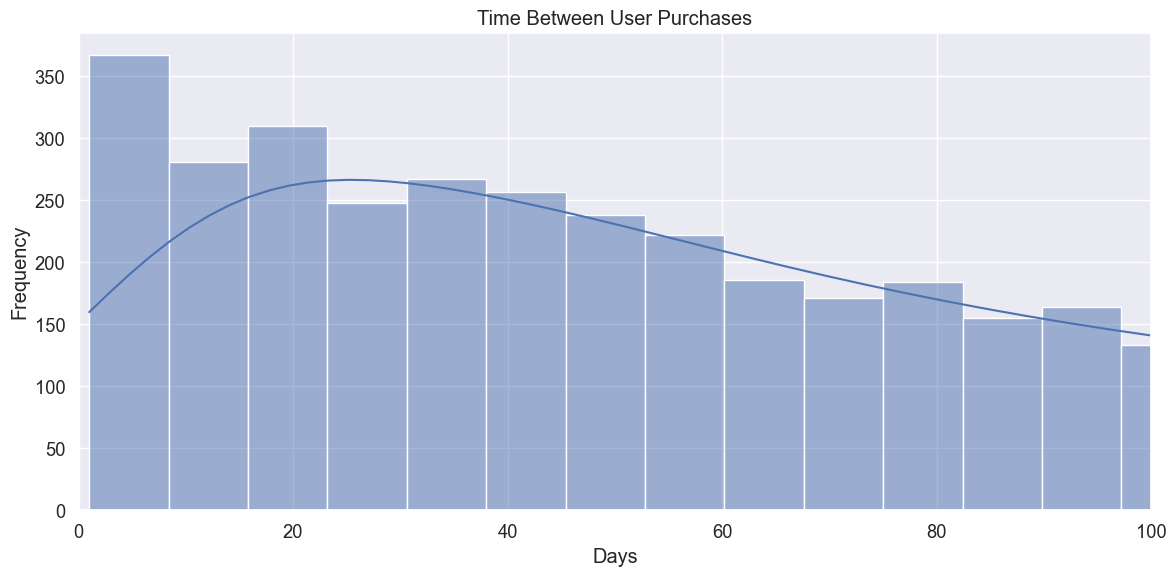

Average days between purchases: 90.42
Median days between purchases: 70.00


In [14]:
# Calculate time between purchases for each user
purchase_intervals = []
for user, group in train_data.groupby('User_id'):
    dates = sorted(group['Date'].unique())
    if len(dates) > 1:  # Only users with multiple purchase dates
        intervals = [(dates[i] - dates[i-1]).days for i in range(1, len(dates))]
        purchase_intervals.extend(intervals)

plt.figure(figsize=(12, 6))
sns.histplot(purchase_intervals, bins=50, kde=True)
plt.title('Time Between User Purchases')
plt.xlabel('Days')
plt.ylabel('Frequency')
plt.xlim(0, 100)  # Focus on shorter intervals
plt.tight_layout()
plt.show()

print(f"Average days between purchases: {np.mean(purchase_intervals):.2f}")
print(f"Median days between purchases: {np.median(purchase_intervals):.2f}")


### 1.3 Prepare Transaction Data for Pattern Mining  
Prepare our data in the right format for pattern mining:

In [ ]:
def prepare_transactions(data):
    # Group by user and date
    transactions = defaultdict(list)
    for _, row in data.iterrows():
        key = (row['User_id'], row['Date']) # group item in the dataset by User_id and Date, name it as transaction
        if pd.notna(row['itemDescription']):  # Skip null items
            transactions[key].append(row['itemDescription'])
    
    # Convert to list of lists
    transaction_list = list(transactions.values())
    
    # Print some statistics
    transaction_sizes = [len(t) for t in transaction_list]
    print(f"Number of transactions: {len(transaction_list)}")
    print(f"Average transaction size: {np.mean(transaction_sizes):.2f} items")
    print(f"Largest transaction: {max(transaction_sizes)} items")
    
    return transaction_list

# Create transaction data
transactions = prepare_transactions(train_data)

Number of transactions: 8361
Average transaction size: 2.32 items
Largest transaction: 9 items


In [17]:
# Show a few sample transactions
print("\nSample transactions:")
for t in transactions[:5]:
    print(t)


Sample transactions:
['cleaner', 'shopping bags']
['sausage', 'bottled water']
['tropical fruit', 'other vegetables']
['whole milk', 'flower (seeds)']
['citrus fruit', 'coffee']


## 2. Implementing the Apriori Algorithm

In [ ]:
class AprioriMiner:
    def __init__(self, min_support=0.005):
        self.min_support = min_support
        self.transactions = None
        self.num_transactions = 0
        self.frequent_itemsets = {}
        self.item_support = {}
    
    # Find all frequent subsets
    def fit(self, transactions):
        """
        Find frequent itemsets using the Apriori algorithm.
        
        Parameters:
        -----------
        transactions : list of lists
            List of transactions, where each transaction is a list of items
        
        Returns:
        --------
        dict
            Dictionary with keys as itemset size and values as list of (itemset, support) tuples
        """
        self.transactions = transactions
        self.num_transactions = len(transactions)
        
        # Step 1: Count support for each individual item
        item_counts = defaultdict(int)
        for transaction in transactions:
            for item in set(transaction):  # Use set to count each item once per transaction
                item_counts[item] += 1
        
        # Filter by minimum support
        min_count = self.min_support * self.num_transactions
        self.item_support = {item: count/self.num_transactions for item, count in item_counts.items() 
                           if count >= min_count}
        
        # Initialize L1 (frequent 1-itemsets)
        L1 = [frozenset([item]) for item in self.item_support.keys()]
        current_L = L1
        k = 1
        
        # Store all frequent itemsets
        self.frequent_itemsets = {
            k: [(itemset, self.item_support[list(itemset)[0]]) for itemset in L1]
        }
        # ========================
        # Main Apriori loop
        while current_L:
            k += 1
            # Generate candidate k-itemsets
            Ck = self._generate_candidates(current_L, k)
            
            if not Ck:
                break  # No candidates generated
                
            # Count support for candidates
            itemset_counts = defaultdict(int)
            for transaction in transactions:
                transaction_set = set(transaction)
                for candidate in Ck:
                    if candidate.issubset(transaction_set):
                        itemset_counts[candidate] += 1
            
            # Filter by minimum support
            Lk = [itemset for itemset, count in itemset_counts.items() 
                 if count >= min_count]
            
            # Store k-itemsets with their support
            if Lk:
                self.frequent_itemsets[k] = [(itemset, itemset_counts[itemset]/self.num_transactions) 
                                           for itemset in Lk]
            
            # Prepare for next iteration
            current_L = Lk
        
        return self.frequent_itemsets
    
    def _generate_candidates(self, prev_itemsets, k):
        """Generate candidate k-itemsets from (k-1)-itemsets"""
        candidates = set()
        
        # For more efficient processing, convert to list of sets
        prev_sets = [set(itemset) for itemset in prev_itemsets]
        
        # For each pair of (k-1)-itemsets
        for i in range(len(prev_sets)):
            for j in range(i+1, len(prev_sets)):
                # Join step
                union = prev_sets[i].union(prev_sets[j])
                if len(union) == k:
                    # Check if all (k-1) subsets are frequent
                    is_valid = True
                    for item in union: # get subset including (k-1) items from current k-item set
                        subset = union - {item}
                        # If one of the subset of the current set is NOT frequent
                        if frozenset(subset) not in prev_itemsets: #[frozenset(s) for s in prev_itemsets]:
                            is_valid = False
                            break
                    
                    if is_valid:
                        candidates.add(frozenset(union)) 
        # Return all sets having k items whose all (k-1) subsets frequent
        return list(candidates)
    
    def generate_rules(self, min_confidence=0.5):
        """
        Generate association rules from frequent itemsets.
        
        Parameters:
        -----------
        min_confidence : float, default=0.5
            Minimum confidence threshold for rules
        
        Returns:
        --------
        list
            List of (antecedent, consequent, support, confidence, lift) tuples
        """
        rules = []
        
        # Helper function to find support for an itemset
        def find_support(itemset):
            k = len(itemset)
            # for k in self.frequent_itemsets:
            for (candidate, support) in self.frequent_itemsets[k]:
                if candidate == itemset:
                    return support
            return 0  # Should not happen for frequent itemsets
        
        # For each k-itemset where k >= 2
        for k in self.frequent_itemsets:
            # Cannot create rules with a set of only 1 item
            if k < 2:
                continue
            # print('hi') 
            for itemset, itemset_support in self.frequent_itemsets[k]:
                
                # Generate all non-empty proper subsets
                subsets = []
                for i in range(1, k):
                    subsets.extend([frozenset(subset) for subset in combinations(itemset, i)])
                # print(subsets)
                # For each subset, create a rule
                for antecedent in subsets: # Take the subsets array as array of all entecedents => itemset - antecedent = consequent set
                    consequent = itemset - antecedent
                    
                    # Skip empty consequents
                    if not consequent:
                        continue
                    
                    # A=>B: Calculate CONFIDENCE P(A, B) / P(A)
                    antecedent_support = find_support(antecedent)
                    confidence = itemset_support / antecedent_support
                    
                    if confidence >= min_confidence:
                        # A= > B: Calculate LIFT P(A, B) /(P(A)*P(B))
                        consequent_support = find_support(consequent)
                        lift = confidence / consequent_support
                        
                        rules.append({
                            'antecedent': list(antecedent),
                            'consequent': list(consequent),
                            'support': itemset_support,
                            'confidence': confidence,
                            'lift': lift
                        })
        
        return rules

In [185]:
# Run the Apriori algorithm on our transaction data
min_support = 0.02/100  # 1%
miner = AprioriMiner(min_support=min_support)
frequent_itemsets = miner.fit(transactions)

In [186]:
miner.frequent_itemsets

{1: [(frozenset({'shopping bags'}), 0.0527448869752422),
  (frozenset({'cleaner'}), 0.002272455447912929),
  (frozenset({'sausage'}), 0.02571462743690946),
  (frozenset({'bottled water'}), 0.06075828250209305),
  (frozenset({'other vegetables'}), 0.10668580313359646),
  (frozenset({'tropical fruit'}), 0.048797990670972374),
  (frozenset({'flower (seeds)'}), 0.005621337160626719),
  (frozenset({'whole milk'}), 0.1304867838775266),
  (frozenset({'coffee'}), 0.03061834708766894),
  (frozenset({'citrus fruit'}), 0.03456524339193876),
  (frozenset({'dishes'}), 0.008850615955029303),
  (frozenset({'onions'}), 0.015787585217079295),
  (frozenset({'whipped/sour cream'}), 0.04437268269345772),
  (frozenset({'yogurt'}), 0.07857911733046287),
  (frozenset({'berries'}), 0.016265996890324125),
  (frozenset({'hamburger meat'}), 0.017222820236813777),
  (frozenset({'frozen potato products'}), 0.005382131324004306),
  (frozenset({'candles'}), 0.004186102140892238),
  (frozenset({'Instant food products

In [187]:
# Print the number of frequent itemsets by size
for k in sorted(frequent_itemsets.keys()):
    print(f"Number of frequent {k}-itemsets: {len(frequent_itemsets[k])}")

Number of frequent 1-itemsets: 163
Number of frequent 2-itemsets: 2230
Number of frequent 3-itemsets: 217
Number of frequent 4-itemsets: 3


In [188]:
# Display top frequent itemsets by support
all_itemsets = []
for k in frequent_itemsets:
    all_itemsets.extend([(list(itemset), support, k) for itemset, support in frequent_itemsets[k]])

print("\nTop 20 frequent itemsets by support:")
for i, (itemset, support, size) in enumerate(sorted(all_itemsets, key=lambda x: x[1], reverse=True)[:20]):
    print(f"{i+1}. {itemset} (size: {size}, support: {support:.4f})")


Top 20 frequent itemsets by support:
1. ['whole milk'] (size: 1, support: 0.1305)
2. ['other vegetables'] (size: 1, support: 0.1067)
3. ['rolls/buns'] (size: 1, support: 0.1019)
4. ['soda'] (size: 1, support: 0.0946)
5. ['yogurt'] (size: 1, support: 0.0786)
6. ['bottled water'] (size: 1, support: 0.0608)
7. ['root vegetables'] (size: 1, support: 0.0604)
8. ['shopping bags'] (size: 1, support: 0.0527)
9. ['pastry'] (size: 1, support: 0.0496)
10. ['tropical fruit'] (size: 1, support: 0.0488)
11. ['whipped/sour cream'] (size: 1, support: 0.0444)
12. ['newspapers'] (size: 1, support: 0.0414)
13. ['bottled beer'] (size: 1, support: 0.0405)
14. ['brown bread'] (size: 1, support: 0.0402)
15. ['domestic eggs'] (size: 1, support: 0.0397)
16. ['pip fruit'] (size: 1, support: 0.0376)
17. ['fruit/vegetable juice'] (size: 1, support: 0.0367)
18. ['margarine'] (size: 1, support: 0.0354)
19. ['citrus fruit'] (size: 1, support: 0.0346)
20. ['canned beer'] (size: 1, support: 0.0342)


In [217]:
for k in frequent_itemsets.keys():
    print(f'Top 20 frequent {k}-itemsets by support',)
    for i, (itemset, support) in enumerate(sorted(frequent_itemsets[k], key = lambda x:x[1], reverse=True)[:min(20, len(frequent_itemsets[k]))]):
        print(f"{i+1}. {itemset} (size: {k}, support: {support:.4f})")           
    print('=========================')                                                                                       

Top 20 frequent 1-itemsets by support
1. frozenset({'whole milk'}) (size: 1, support: 0.1305)
2. frozenset({'other vegetables'}) (size: 1, support: 0.1067)
3. frozenset({'rolls/buns'}) (size: 1, support: 0.1019)
4. frozenset({'soda'}) (size: 1, support: 0.0946)
5. frozenset({'yogurt'}) (size: 1, support: 0.0786)
6. frozenset({'bottled water'}) (size: 1, support: 0.0608)
7. frozenset({'root vegetables'}) (size: 1, support: 0.0604)
8. frozenset({'shopping bags'}) (size: 1, support: 0.0527)
9. frozenset({'pastry'}) (size: 1, support: 0.0496)
10. frozenset({'tropical fruit'}) (size: 1, support: 0.0488)
11. frozenset({'whipped/sour cream'}) (size: 1, support: 0.0444)
12. frozenset({'newspapers'}) (size: 1, support: 0.0414)
13. frozenset({'bottled beer'}) (size: 1, support: 0.0405)
14. frozenset({'brown bread'}) (size: 1, support: 0.0402)
15. frozenset({'domestic eggs'}) (size: 1, support: 0.0397)
16. frozenset({'pip fruit'}) (size: 1, support: 0.0376)
17. frozenset({'fruit/vegetable juice'}

generate and analyze association rules:

In [189]:
# Generate association rules
min_confidence = 0.3  # 30%
rules = miner.generate_rules(min_confidence=min_confidence)

print(f"Generated {len(rules)} association rules with min confidence {min_confidence}")

# Sort rules by lift
sorted_rules = sorted(rules, key=lambda x: x['lift'], reverse=True)

# Display top rules by lift
print("\nTop 20 association rules by lift:")
for i, rule in enumerate(sorted_rules[:20]):
    print(f"{i+1}. {rule['antecedent']} => {rule['consequent']} "
          f"(support: {rule['support']:.4f}, confidence: {rule['confidence']:.4f}, lift: {rule['lift']:.4f})")

[frozenset({'sausage'}), frozenset({'bottled water'})]
[frozenset({'other vegetables'}), frozenset({'tropical fruit'})]
[frozenset({'whole milk'}), frozenset({'flower (seeds)'})]
[frozenset({'coffee'}), frozenset({'citrus fruit'})]
[frozenset({'dishes'}), frozenset({'onions'})]
[frozenset({'onions'}), frozenset({'whipped/sour cream'})]
[frozenset({'dishes'}), frozenset({'whipped/sour cream'})]
[frozenset({'yogurt'}), frozenset({'other vegetables'})]
[frozenset({'berries'}), frozenset({'bottled water'})]
[frozenset({'whipped/sour cream'}), frozenset({'bottled water'})]
[frozenset({'candles'}), frozenset({'hamburger meat'})]
[frozenset({'Instant food products'}), frozenset({'yogurt'})]
[frozenset({'Instant food products'}), frozenset({'other vegetables'})]
[frozenset({'domestic eggs'}), frozenset({'hamburger meat'})]
[frozenset({'domestic eggs'}), frozenset({'bottled beer'})]
[frozenset({'bottled beer'}), frozenset({'hamburger meat'})]
[frozenset({'butter'}), frozenset({'frozen vegetable

In [157]:
# miner.generate_rules(min_confidence=min_confidence)

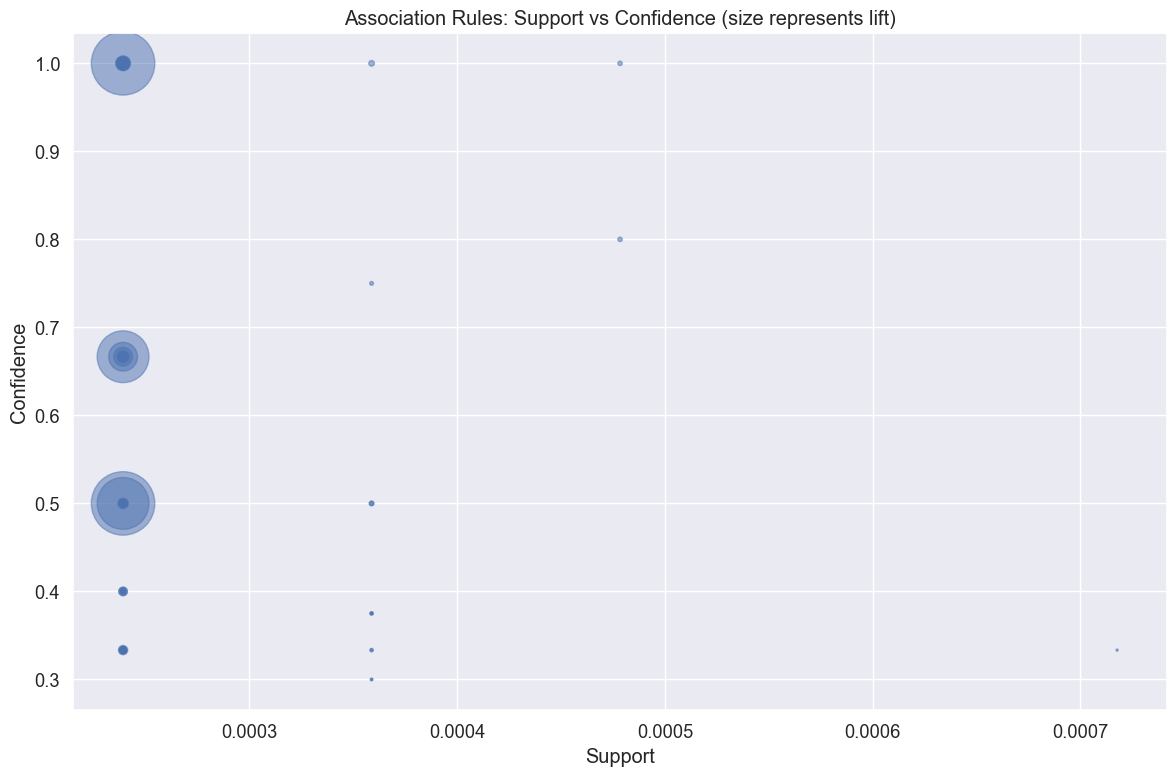

In [190]:
# Visualize rule metrics
rule_df = pd.DataFrame(sorted_rules)

plt.figure(figsize=(12, 8))
plt.scatter(rule_df['support'], rule_df['confidence'], 
            s=rule_df['lift'], alpha=0.5)
plt.title('Association Rules: Support vs Confidence (size represents lift)')
plt.xlabel('Support')
plt.ylabel('Confidence')
plt.grid(True)
plt.tight_layout()
plt.show()

## 3. Advanced Pattern Scoring  
Implement our custom pattern scoring metrics

In [191]:
class PatternScorer:
    def __init__(self, transactions, frequent_itemsets, item_support):
        self.transactions = transactions
        self.frequent_itemsets = frequent_itemsets
        self.item_support = item_support
        self.user_data = None
    
    def add_user_data(self, data):
        """Add user-specific data for personalized scoring"""
        self.user_data = data
        
        # Prepare user profiles
        self.user_item_frequencies = defaultdict(lambda: defaultdict(int)) 
        #This dictionary stores user's latest date making purchase on each item
        self.user_last_purchase = defaultdict(lambda: defaultdict(str))
        
        # Group data by user
        for _, row in data.iterrows():
            user = row['User_id']
            item = row['itemDescription']
            date = row['Date']
            
            # Update frequency
            self.user_item_frequencies[user][item] += 1
            
            # Update last purchase date if needed (if we found a new record of current user purchasing same item but more recent) 
            if item not in self.user_last_purchase[user] or date > self.user_last_purchase[user][item]:
                self.user_last_purchase[user][item] = date
    
    def score_patterns(self, method='combined', user_id=None, top_n=None):
        """
        Score patterns using various metrics.
        
        Parameters:
        -----------
        method : str, default='combined'
            Scoring method: 'support', 'lift', 'recency', or 'combined'
        user_id : int, optional
            If provided, personalize scores for this user
        top_n : int, optional
            If provided, return only top N patterns
        
        Returns:
        --------
        list
            Scored patterns as (itemset, score) tuples
        """
        # Create a flat list of all itemsets with their supports
        all_itemsets = []
        for k in self.frequent_itemsets:
            all_itemsets.extend([(frozenset(itemset), support) 
                                for itemset, support in self.frequent_itemsets[k]])
        
        # Apply scoring method
        if method == 'support':
            scored_patterns = [(list(itemset), support) for itemset, support in all_itemsets]
        
        elif method == 'lift':
            scored_patterns = []
            for itemset, support in all_itemsets:
                if len(itemset) <= 1:
                    # For single items, just use support
                    scored_patterns.append((list(itemset), support))
                else:
                    # Calculate average lift for this pattern
                    avg_lift = self._calculate_pattern_lift(itemset, support)
                    # WEIGHT BY SUPPORT==============
                    # score = avg_lift * support
                    score = avg_lift
                    scored_patterns.append((list(itemset), score))
        
        elif method == 'recency':
            if user_id is None or self.user_data is None:
                raise ValueError("User ID and user data required for recency scoring")
            
            scored_patterns = []
            for itemset, support in all_itemsets:
                # Calculate recency score
                recency_score = self._calculate_recency_score(itemset, user_id)
                # Combine with support
                # score = recency_score * support
                score = recency_score
                scored_patterns.append((list(itemset), score))
        
        elif method == 'combined':
            # Define weights for different factors
            w_support = 0.4
            w_lift = 0.3
            w_recency = 0.2
            w_frequency = 0.1
            
            scored_patterns = []
            for itemset, support in all_itemsets:
                # Start with support component
                score_components = [support * w_support]
                
                # Add lift component for multi-item patterns
                if len(itemset) > 1:
                    lift = self._calculate_pattern_lift(itemset, support)
                    score_components.append(lift * w_lift)
                else:
                    # For 1-itemsets, still add the weight
                    score_components.append(w_lift)
                
                # Add user-specific components if available
                if user_id is not None and self.user_data is not None:
                    # Recency component
                    recency = self._calculate_recency_score(itemset, user_id)
                    score_components.append(recency * w_recency)
                    
                    # Frequency component
                    frequency = self._calculate_frequency_score(itemset, user_id)
                    score_components.append(frequency * w_frequency)
                else:
                    # Without user data, add the weights
                    score_components.extend([w_recency, w_frequency])
                
                # Calculate final score
                final_score = sum(score_components)
                scored_patterns.append((list(itemset), final_score))
        
        else:
            raise ValueError(f"Unknown scoring method: {method}")
        
        # Sort by score (descending)
        scored_patterns.sort(key=lambda x: x[1], reverse=True)
        
        # Return top N if specified
        if top_n is not None:
            return scored_patterns[:top_n]
        return scored_patterns
    
    def _calculate_pattern_lift(self, pattern, pattern_support):
        """Calculate average lift across all possible rules from this pattern"""
        if len(pattern) <= 1:
            return 1.0  # No meaningful lift for singleton sets
        
        lifts = []
        
        # For each possible rule A -> B from this pattern
        for i in range(1, len(pattern)): #len(antecedent) from 1 to len(pattern) - 1, antecedent cannot be empty 
            for antecedent_items in combinations(pattern, i):
                antecedent = frozenset(antecedent_items)
                consequent = pattern - antecedent
                
                # Find supports
                antecedent_support = self._get_itemset_support(antecedent)
                consequent_support = self._get_itemset_support(consequent)
                
                if antecedent_support > 0 and consequent_support > 0:
                    # A => B, lift = Supp(A,B)/ (Supp(A) * Supp(B)) = Conf(A,B) / Supp(B)
                    confidence = pattern_support / antecedent_support
                    lift = confidence / consequent_support
                    lifts.append(lift)
        
        # Return average lift
        return sum(lifts) / len(lifts) if lifts else 1.0
    
    def _get_itemset_support(self, itemset):
        """Get support for an itemset"""
        if len(itemset) == 1:
            item = list(itemset)[0]
            return self.item_support.get(item, 0)
        
        # Search in frequent itemsets
        for k in self.frequent_itemsets:
            if k == len(itemset):
                for candidate, support in self.frequent_itemsets[k]:
                    if frozenset(candidate) == itemset:
                        return support
        
        return 0  # Not found (not frequent)
    
    def _calculate_recency_score(self, pattern, user_id):
        """Calculate recency score based on how recently user purchased items"""
        if user_id not in self.user_last_purchase:
            return 0.5  # Default for users with no history
        
        # Get the latest date a purchase was made
        latest_date = max(date for user_dates in self.user_last_purchase.values() 
                         for date in user_dates.values())
        
        # Calculate recency for each item in pattern
        recency_scores = []
        for item in pattern:
            if item in self.user_last_purchase[user_id]:
                last_purchase = self.user_last_purchase[user_id][item]
                days_since = (latest_date - last_purchase).days
                
                # Convert to a normalized score (higher is more recent)
                # Using exponential decay: e^(-days/30)
                recency = math.exp(-days_since / 30)
                recency_scores.append(recency)
        
        # Return average recency
        return sum(recency_scores) / len(recency_scores) if recency_scores else 0.5
    
    def _calculate_frequency_score(self, pattern, user_id):
        """Calculate frequency score based on how often user buys these items"""
        if user_id not in self.user_item_frequencies:
            return 0.5  # Default for users with no history
        
        # Find the maximum frequency across all users and items
        max_freq = max(freq for user_freq in self.user_item_frequencies.values() 
                      for freq in user_freq.values())
        
        # Calculate normalized frequency for each item in pattern
        freq_scores = []
        for item in pattern:
            if item in self.user_item_frequencies[user_id]:
                # Normalize by max frequency
                norm_freq = self.user_item_frequencies[user_id][item] / max_freq
                freq_scores.append(norm_freq)
        
        # Return average frequency
        return sum(freq_scores) / len(freq_scores) if freq_scores else 0.5

In [192]:
# Create pattern scorer and score patterns
scorer = PatternScorer(transactions, frequent_itemsets, miner.item_support)
scorer.add_user_data(train_data)
# Get general patterns with combined scoring
general_patterns = scorer.score_patterns(method='combined', top_n=20)
print("Top 20 patterns by combined score:")
for i, (pattern, score) in enumerate(general_patterns, 1):
    print(f"{i}. {pattern} (score: {score:.4f})")


Top 20 patterns by combined score:
1. ['frankfurter', 'dishes', 'citrus fruit', 'whipped/sour cream'] (score: 178.5405)
2. ['vinegar', 'frozen vegetables', 'grapes'] (score: 32.1123)
3. ['frankfurter', 'dishes', 'citrus fruit'] (score: 17.9583)
4. ['soda', 'hard cheese', 'other vegetables', 'newspapers'] (score: 14.5682)
5. ['flower (seeds)', 'honey'] (score: 12.1597)
6. ['frankfurter', 'dishes', 'whipped/sour cream'] (score: 11.5504)
7. ['house keeping products', 'jam'] (score: 10.0790)
8. ['pickled vegetables', 'rolls/buns', 'ham'] (score: 8.2167)
9. ['sugar', 'frankfurter', 'brown bread'] (score: 7.2719)
10. ['canned fish', 'cocoa drinks'] (score: 7.0793)
11. ['pickled vegetables', 'soda', 'ham'] (score: 6.5300)
12. ['whole milk', 'flower (seeds)', 'pork'] (score: 6.0760)
13. ['specialty bar', 'newspapers', 'white bread'] (score: 6.0405)
14. ['cookware', 'oil'] (score: 6.0334)
15. ['processed cheese', 'liver loaf'] (score: 5.8990)
16. ['soft cheese', 'whole milk', 'hamburger meat'] 

In [193]:
# Get patterns for a specific user
sample_user_id = train_data['User_id'].iloc[0]  # Just using the first user as an example
user_patterns = scorer.score_patterns(method='combined', user_id=sample_user_id, top_n=10)

print(f"\nTop 10 patterns for user {sample_user_id}:")
for i, (pattern, score) in enumerate(user_patterns, 1):
    print(f"{i}. {pattern} (score: {score:.4f})")


Top 10 patterns for user 2351:
1. ['frankfurter', 'dishes', 'citrus fruit', 'whipped/sour cream'] (score: 178.3905)
2. ['vinegar', 'frozen vegetables', 'grapes'] (score: 31.9623)
3. ['frankfurter', 'dishes', 'citrus fruit'] (score: 17.8083)
4. ['soda', 'hard cheese', 'other vegetables', 'newspapers'] (score: 14.4182)
5. ['flower (seeds)', 'honey'] (score: 12.0097)
6. ['frankfurter', 'dishes', 'whipped/sour cream'] (score: 11.4004)
7. ['house keeping products', 'jam'] (score: 9.9290)
8. ['pickled vegetables', 'rolls/buns', 'ham'] (score: 8.0667)
9. ['sugar', 'frankfurter', 'brown bread'] (score: 7.1219)
10. ['canned fish', 'cocoa drinks'] (score: 6.9293)


## 4. Evaluating Pattern Quality   
evaluate mined patterns' quality

In [194]:
#Evaluate if patterns are meaningful
def evaluate_pattern_quality(patterns, transactions):
    """Calculate coverage and redundancy metrics for patterns"""
    # Calculate coverage (what percentage of transactions contain at least one pattern)
    covered_transactions = 0
    for transaction in transactions:
        transaction_set = set(transaction)
        is_covered = False
        for pattern, _ in patterns:
            pattern_set = set(pattern)
            if pattern_set.issubset(transaction_set):
                is_covered = True
                break
        if is_covered:
            covered_transactions += 1
    
    coverage = covered_transactions / len(transactions)
    
    # Calculate redundancy (average Jaccard similarity between patterns)
    similarities = []
    for i, (pattern1, _) in enumerate(patterns):
        for j, (pattern2, _) in enumerate(patterns):
            if i < j:  # Only compare each pair once
                set1 = set(pattern1)
                set2 = set(pattern2)
                
                # Jaccard similarity
                intersection = len(set1.intersection(set2))
                union = len(set1.union(set2))
                if union > 0:
                    similarity = intersection / union
                    similarities.append(similarity)
    
    redundancy = sum(similarities) / len(similarities) if similarities else 0
    
    return {
        'coverage': coverage,
        'redundancy': redundancy
    }

In [195]:
# Evaluate our pattern quality
pattern_quality = evaluate_pattern_quality(general_patterns, transactions)
print(f"Pattern quality metrics:")
print(f"Coverage: {pattern_quality['coverage']:.4f}") # (higher is better)
print(f"Redundancy: {pattern_quality['redundancy']:.4f}") # (lower is better)


Pattern quality metrics:
Coverage: 0.0039
Redundancy: 0.0326


## 5. Conclusion and Pattern Mining Module

In [179]:
class FrequentPatternMiner:
    """
    A class for mining and scoring frequent patterns from grocery transaction data.
    """
    
    def __init__(self, min_support=0.005, min_confidence=0.3):
        """
        Initialize the pattern miner.
        
        Parameters:
        -----------
        min_support : float, default=0.005
            Minimum support threshold (between 0 and 1)
        min_confidence : float, default=0.3
            Minimum confidence threshold for association rules
        """
        self.min_support = min_support
        self.min_confidence = min_confidence
        self.apriori_miner = None
        self.pattern_scorer = None
        self.transactions = None
    def prepare_transactions(self, data):
        """
        Convert raw data to transaction format.
        
        Parameters:
        -----------
        data : pandas.DataFrame
            Raw input data
        
        Returns:
        --------
        list of lists
            Transactions in the right format for pattern mining
        """
        # Group by user and date
        transactions = defaultdict(list)
        for _, row in data.iterrows():
            key = (row['User_id'], row['Date'])
            if pd.notna(row['itemDescription']):  # Skip null items
                transactions[key].append(row['itemDescription'])
        
        # Convert to list of lists
        transaction_list = list(transactions.values())
        return transaction_list
    
    def fit(self, data, user_id=None):
        """
        Mine frequent patterns from the data.
        
        Parameters:
        -----------
        data : pandas.DataFrame
            Raw input data
        user_id : int, optional
            If provided, focus on this user's data
        
        Returns:
        --------
        self
        """
        # Prepare transactions
        if user_id is not None:
            # Filter data for specific user
            user_data = data[data['User_id'] == user_id]
            if len(user_data) > 0:
                self.transactions = self.prepare_transactions(user_data)
            else:
                # User has no data, use all data
                self.transactions = self.prepare_transactions(data)
        else:
            self.transactions = self.prepare_transactions(data)
        
        # Run Apriori
        self.apriori_miner = AprioriMiner(min_support=self.min_support)
        frequent_itemsets = self.apriori_miner.fit(self.transactions)
        
        # Create pattern scorer
        self.pattern_scorer = PatternScorer(
            self.transactions, 
            frequent_itemsets, 
            self.apriori_miner.item_support
        )
        self.pattern_scorer.add_user_data(data)
        
        return self
    
    def get_patterns(self, method='combined', user_id=None, top_n=10):
        """
        Get scored patterns.
        
        Parameters:
        -----------
        method : str, default='combined'
            Scoring method: 'support', 'lift', 'recency', or 'combined'
        user_id : int, optional
            If provided, personalize scores for this user
        top_n : int, default=10
            Number of patterns to return
        
        Returns:
        --------
        list
            List of (pattern, score) tuples
        """
        if self.pattern_scorer is None:
            raise ValueError("You must call fit() before get_patterns()")
        
        return self.pattern_scorer.score_patterns(
            method=method, 
            user_id=user_id, 
            top_n=top_n
        )
    
    def get_rules(self, top_n=20):
        """
        Get association rules.
        
        Parameters:
        -----------
        top_n : int, default=20
            Number of rules to return
            
        Returns:
        --------
        list
            List of association rules
        """
        if self.apriori_miner is None:
            raise ValueError("You must call fit() before get_rules()")
        
        rules = self.apriori_miner.generate_rules(min_confidence=self.min_confidence)
        
        # Sort by lift
        sorted_rules = sorted(rules, key=lambda x: x['lift'], reverse=True)
        
        return sorted_rules[:top_n]

In [196]:
# Example usage of the final module
# Create an instance
miner = FrequentPatternMiner(min_support=0.02/100, min_confidence=0.3)

# Fit the model
miner.fit(train_data)

# Get top patterns with combined scoring
top_patterns = miner.get_patterns(method='combined', top_n=15)
print("Top 15 patterns with combined scoring:")
for i, (pattern, score) in enumerate(top_patterns, 1):
    print(f"{i}. {pattern} (score: {score:.4f})")

# Get top association rules
top_rules = miner.get_rules(top_n=10)
print("\nTop 10 association rules by lift:")
for i, rule in enumerate(top_rules, 1):
    print(f"{i}. {rule['antecedent']} => {rule['consequent']} "
          f"(support: {rule['support']:.4f}, confidence: {rule['confidence']:.4f}, lift: {rule['lift']:.4f})")

Top 15 patterns with combined scoring:
1. ['frankfurter', 'dishes', 'citrus fruit', 'whipped/sour cream'] (score: 178.5405)
2. ['vinegar', 'frozen vegetables', 'grapes'] (score: 32.1123)
3. ['frankfurter', 'dishes', 'citrus fruit'] (score: 17.9583)
4. ['soda', 'hard cheese', 'other vegetables', 'newspapers'] (score: 14.5682)
5. ['flower (seeds)', 'honey'] (score: 12.1597)
6. ['frankfurter', 'dishes', 'whipped/sour cream'] (score: 11.5504)
7. ['house keeping products', 'jam'] (score: 10.0790)
8. ['pickled vegetables', 'rolls/buns', 'ham'] (score: 8.2167)
9. ['sugar', 'frankfurter', 'brown bread'] (score: 7.2719)
10. ['canned fish', 'cocoa drinks'] (score: 7.0793)
11. ['pickled vegetables', 'soda', 'ham'] (score: 6.5300)
12. ['whole milk', 'flower (seeds)', 'pork'] (score: 6.0760)
13. ['specialty bar', 'newspapers', 'white bread'] (score: 6.0405)
14. ['cookware', 'oil'] (score: 6.0334)
15. ['processed cheese', 'liver loaf'] (score: 5.8990)
[frozenset({'sausage'}), frozenset({'bottled wat

## 6. Analyzing Pattern Mining Results

c:\Users\ASUS\.conda\envs\myenv\Lib\site-packages\seaborn\_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


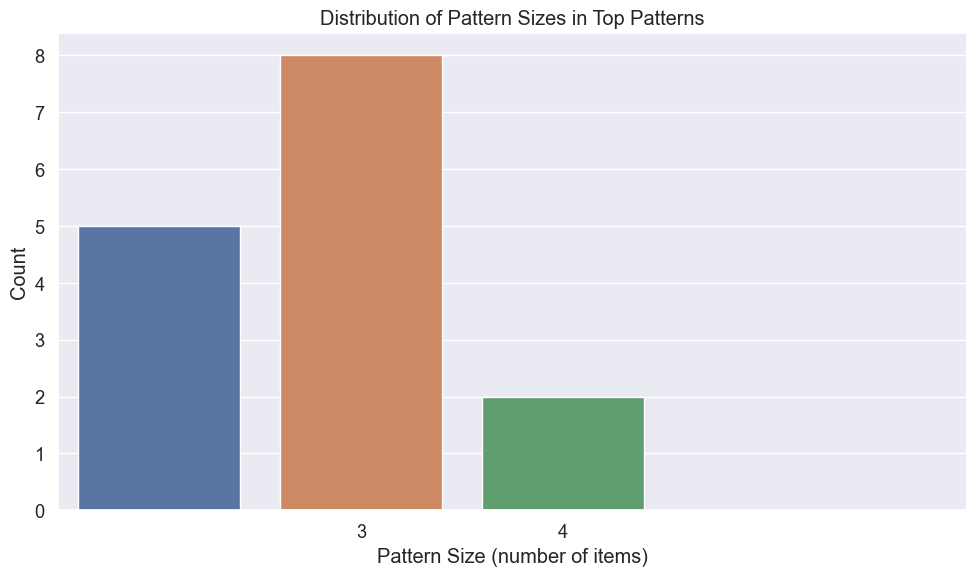

In [197]:
# Visualize pattern sizes
pattern_sizes = [len(pattern) for pattern, _ in top_patterns]

plt.figure(figsize=(10, 6))
sns.countplot(x=pattern_sizes)
plt.title('Distribution of Pattern Sizes in Top Patterns')
plt.xlabel('Pattern Size (number of items)')
plt.ylabel('Count')
plt.xticks(range(1, max(pattern_sizes)+1))
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()

c:\Users\ASUS\.conda\envs\myenv\Lib\site-packages\seaborn\_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


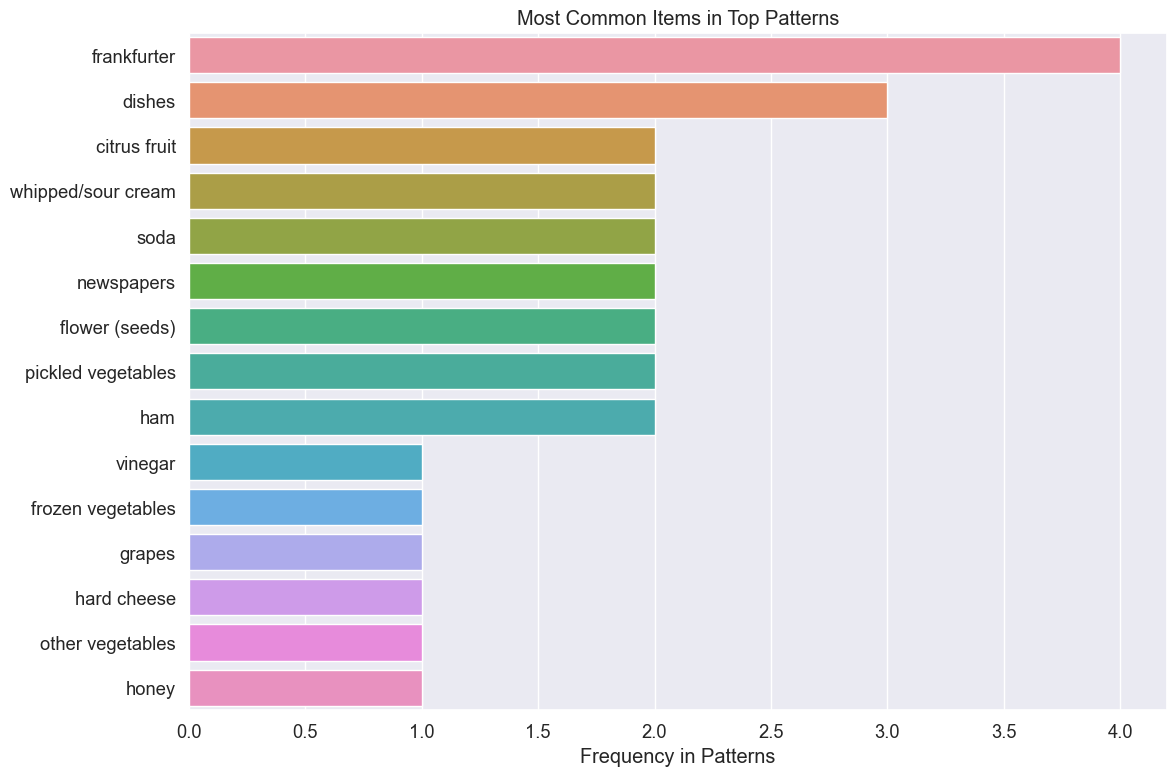

In [198]:
# Analyze item frequency in top patterns
item_in_patterns = defaultdict(int)
for pattern, _ in top_patterns:
    for item in pattern:
        item_in_patterns[item] += 1

# Plot top items in patterns
top_pattern_items = sorted(item_in_patterns.items(), key=lambda x: x[1], reverse=True)[:15]
item_names = [item for item, _ in top_pattern_items]
item_counts = [count for _, count in top_pattern_items]

plt.figure(figsize=(12, 8))
sns.barplot(x=item_counts, y=item_names)
plt.title('Most Common Items in Top Patterns')
plt.xlabel('Frequency in Patterns')
plt.tight_layout()
plt.show()

## 7. User-Specific Pattern Analysis

Let's analyze patterns for specific users:

In [199]:



# Get a few sample users
sample_users = train_data['User_id'].sample(5).tolist()

# Analyze patterns for each user
for user_id in sample_users:
    # Get user data
    user_data = train_data[train_data['User_id'] == user_id]
    print(f"\nUser {user_id}: {len(user_data)} items in {user_data['Date'].nunique()} transactions")
    
    # Get user's top purchased items
    top_items = user_data['itemDescription'].value_counts().head(5)
    print("Top 5 purchased items:")
    for item, count in top_items.items():
        print(f"  - {item}: {count} times")
    
    # Get personalized patterns
    user_patterns = miner.get_patterns(method='combined', user_id=user_id, top_n=5)
    print("Top 5 personalized patterns:")
    for i, (pattern, score) in enumerate(user_patterns, 1):
        print(f"  {i}. {pattern} (score: {score:.4f})")
    
    print("-" * 50)


User 4510: 8 items in 4 transactions
Top 5 purchased items:
  - whole milk: 1 times
  - cream cheese : 1 times
  - other vegetables: 1 times
  - butter: 1 times
  - sausage: 1 times
Top 5 personalized patterns:
  1. ['frankfurter', 'dishes', 'citrus fruit', 'whipped/sour cream'] (score: 178.3009)
  2. ['vinegar', 'frozen vegetables', 'grapes'] (score: 31.9623)
  3. ['frankfurter', 'dishes', 'citrus fruit'] (score: 17.7187)
  4. ['soda', 'hard cheese', 'other vegetables', 'newspapers'] (score: 14.3084)
  5. ['flower (seeds)', 'honey'] (score: 12.0097)
--------------------------------------------------

User 2973: 12 items in 5 transactions
Top 5 purchased items:
  - yogurt: 1 times
  - semi-finished bread: 1 times
  - flour: 1 times
  - napkins: 1 times
  - waffles: 1 times
Top 5 personalized patterns:
  1. ['frankfurter', 'dishes', 'citrus fruit', 'whipped/sour cream'] (score: 178.3905)
  2. ['vinegar', 'frozen vegetables', 'grapes'] (score: 31.8887)
  3. ['frankfurter', 'dishes', 'ci

## 8. Pattern Scoring Comparison

In [200]:
# Compare different scoring methods
scoring_methods = ['support', 'lift', 'combined']
user_id = sample_users[0]  # Use the first sample user

print(f"Comparing scoring methods for user {user_id}:")
for method in scoring_methods:
    patterns = miner.get_patterns(method=method, user_id=user_id, top_n=5)
    
    print(f"\nTop 5 patterns using {method} scoring:")
    for i, (pattern, score) in enumerate(patterns, 1):
        print(f"  {i}. {pattern} (score: {score:.4f})")

Comparing scoring methods for user 4510:

Top 5 patterns using support scoring:
  1. ['whole milk'] (score: 0.1305)
  2. ['other vegetables'] (score: 0.1067)
  3. ['rolls/buns'] (score: 0.1019)
  4. ['soda'] (score: 0.0946)
  5. ['yogurt'] (score: 0.0786)

Top 5 patterns using lift scoring:
  1. ['frankfurter', 'dishes', 'citrus fruit', 'whipped/sour cream'] (score: 594.1348)
  2. ['vinegar', 'frozen vegetables', 'grapes'] (score: 106.0407)
  3. ['frankfurter', 'dishes', 'citrus fruit'] (score: 58.8607)
  4. ['soda', 'hard cheese', 'other vegetables', 'newspapers'] (score: 47.5603)
  5. ['flower (seeds)', 'honey'] (score: 39.5319)

Top 5 patterns using combined scoring:
  1. ['frankfurter', 'dishes', 'citrus fruit', 'whipped/sour cream'] (score: 178.3009)
  2. ['vinegar', 'frozen vegetables', 'grapes'] (score: 31.9623)
  3. ['frankfurter', 'dishes', 'citrus fruit'] (score: 17.7187)
  4. ['soda', 'hard cheese', 'other vegetables', 'newspapers'] (score: 14.3084)
  5. ['flower (seeds)', '

## 9. Recency Effect Analysis

analyze the effect of recency on pattern scoring:

In [204]:
# Analyze how recency affects pattern ranking
user_id = sample_users[3]  # Use the first sample user

# Get user purchase history
user_data = train_data[train_data['User_id'] == user_id]
user_dates = sorted(user_data['Date'].unique())

if len(user_dates) >= 2:
    # Split into early and recent purchases
    split_point = len(user_dates) // 2
    early_dates = user_dates[:split_point]
    recent_dates = user_dates[split_point:]
    
    early_purchases = user_data[user_data['Date'].isin(early_dates)]
    recent_purchases = user_data[user_data['Date'].isin(recent_dates)]
    
    print(f"\nAnalyzing recency effect for user {user_id}:")
    print(f"Early purchases ({early_dates[0]} to {early_dates[-1]}): {len(early_purchases)} items")
    print(f"Recent purchases ({recent_dates[0]} to {recent_dates[-1]}): {len(recent_purchases)} items")
    
    # Compare top items
    early_items = early_purchases['itemDescription'].value_counts().head(5)
    recent_items = recent_purchases['itemDescription'].value_counts().head(5)
    
    print("\nTop 5 items in early purchases:")
    for item, count in early_items.items():
        print(f"  - {item}: {count} times")
    
    print("\nTop 5 items in recent purchases:")
    for item, count in recent_items.items():
        print(f"  - {item}: {count} times")
    
    # Compare with recency-weighted patterns
    recency_patterns = miner.get_patterns(method='recency', user_id=user_id, top_n=5)
    
    print("\nTop 5 patterns with recency scoring:")
    for i, (pattern, score) in enumerate(recency_patterns, 1):
        # Check if pattern items are in recent purchases
        in_recent = sum(1 for item in pattern if item in recent_items)
        print(f"  {i}. {pattern} (score: {score:.4f}, items in recent purchases: {in_recent}/{len(pattern)})")


Analyzing recency effect for user 1922:
Early purchases (2014-01-01 00:00:00 to 2014-05-30 00:00:00): 6 items
Recent purchases (2014-06-04 00:00:00 to 2014-07-11 00:00:00): 6 items

Top 5 items in early purchases:
  - tropical fruit: 1 times
  - other vegetables: 1 times
  - bottled water: 1 times
  - sugar: 1 times
  - whole milk: 1 times

Top 5 items in recent purchases:
  - chocolate: 1 times
  - curd cheese: 1 times
  - yogurt: 1 times
  - whipped/sour cream: 1 times
  - pastry: 1 times

Top 5 patterns with recency scoring:
  1. ['shopping bags'] (score: 0.5000, items in recent purchases: 0/1)
  2. ['cleaner'] (score: 0.5000, items in recent purchases: 0/1)
  3. ['sausage'] (score: 0.5000, items in recent purchases: 0/1)
  4. ['flower (seeds)'] (score: 0.5000, items in recent purchases: 0/1)
  5. ['coffee'] (score: 0.5000, items in recent purchases: 0/1)
